# 3. Model Training & Comparison

In this section, we will build and train machine learning models for our multi-output classification task. Crucially, we will drop the `customer_ID` column before training, as it is a unique identifier that would cause overfitting. We will train Random Forest, XGBoost, and CatBoost models using a Multi-Output wrapper, and compare their performances.

---

### 3. Modellərin Qurulması və Müqayisəsi

Bu bölmədə biz çox-çıxışlı təsnifat (multi-output classification) tapşırığımız üçün maşın öyrənməsi modellərini quracaq və öyrədəcəyik. Ən kritik məqam odur ki, təlimə başlamazdan əvvəl `customer_ID` sütununu siləcəyik, çünki bu unikal identifikator modelin datanı sadəcə əzbərləməsinə (overfitting) səbəb ola bilər. Biz Multi-Output strukturu daxilində Random Forest, XGBoost və CatBoost modellərini öyrədib onların performanslarını müqayisə edəcəyik.

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score

In [4]:
X_raw = pd.read_csv("preprocessed_features.csv")
y_raw = pd.read_csv("preprocessed_targets.csv")

# customer_ID-ni tamamilə silirik (overfitting-in qarşısını almaq üçün)
X = X_raw.drop(columns=["customer_ID"])
y = y_raw.drop(columns=["customer_ID"])

# XGBoost və digər modellər üçün hədəfləri qlobal olaraq 0-dan başladırıq
# Hər sütunun minimum dəyərini yadda saxlayırıq ki, sonda proqnozları geri qaytara bilək
target_shifts = {}
for col in y.columns:
    min_val = y[col].min()
    target_shifts[col] = min_val  # Bu bizə sonda lazım olacaq (+1 etmək üçün)
    y[col] = y[col] - min_val

print("Global target shift values applied:", target_shifts)
print("Features shape (X):", X.shape)
print("Targets shape (y):", y.shape)

Global target shift values applied: {'target_A': np.int64(0), 'target_B': np.int64(0), 'target_C': np.int64(1), 'target_D': np.int64(1), 'target_E': np.int64(0), 'target_F': np.int64(0), 'target_G': np.int64(1)}
Features shape (X): (97009, 29)
Targets shape (y): (97009, 7)


### Observation

As planned, the `customer_ID` column has been successfully dropped from both the feature matrix ($X$) and target matrix ($y$). This ensures that the machine learning models learn genuine customer patterns (like age, risk factors, and cost history) rather than memorizing arbitrary transaction IDs.

### Şərh / Müşahidə

Planlaşdırdığımız kimi, `customer_ID` sütunu həm xüsusiyyətlər matrisindən ($X$), həm də hədəf matrisindən ($y$) uğurla silindi. Bu, maşın öyrənməsi modellərinin təsadüfi ID rəqəmlərini əzbərləmək əvəzinə, müştərilərin real davranış formalarını (yaş, risk faktorları və qiymət tarixçəsi kimi) öyrənməsini təmin edir.

In [5]:
# Split data into train and test sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Train set shape: (77607, 29)
Test set shape: (19402, 29)


### Observation

The dataset is split into an 80% training set and a 20% testing set. The training set will be used to optimize model weights, while the test set will serve as unseen data to evaluate the final generalization performance.

### Şərh / Müşahidə

Dataset 80% təlim (train) və 20% test çoxluğuna ayrıldı. Təlim çoxluğu modelin daxili parametrlərini optimallaşdırmaq üçün istifadə ediləcək, test çoxluğu isə modelin heç görmədiyi yeni datalar üzərindəki real performansını qiymətləndirmək üçün sınaq rolunu oynayacaq.

In [6]:
# 1. Random Forest with Multi-Output wrapper
rf_base = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf_model = MultiOutputClassifier(rf_base)

print("Training Random Forest...")
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
print("Random Forest training completed successfully!")

Training Random Forest...
Random Forest training completed successfully!


### Observation

We trained a Random Forest Classifier wrapped inside a `MultiOutputClassifier`. Since our problem requires predicting 7 target variables simultaneously ($A$ through $G$), the MultiOutput wrapper clones the base model 7 times, training a separate estimator for each distinct insurance component.

### Şərh / Müşahidə

`MultiOutputClassifier` daxilində paketlənmiş bir Random Forest modeli öyrətdik. Problemimiz eyni anda 7 fərqli hədəf dəyişənini ($A$-dan $G$-yə qədər) proqnozlaşdırmağı tələb etdiyi üçün, bu struktur əsas modeli 7 dəfə klonlaşdırır və hər bir sığorta təminatı komponenti üçün ayrıca bir təxminləyici öyrədir.

In [7]:
# 2. XGBoost with Multi-Output wrapper

xgb_base = XGBClassifier(
    n_estimators=100, 
    max_depth=6, 
    learning_rate=0.1, 
    random_state=42, 
    eval_metric='mlogloss'
)
xgb_model = MultiOutputClassifier(xgb_base)

print("Training XGBoost...")
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
print("XGBoost training completed successfully!")

Training XGBoost...
XGBoost training completed successfully!


### Observation

XGBoost, a powerful gradient boosting framework, was trained under the same multi-output conditions. It builds sequential trees to minimize residuals, which usually helps in capturing tighter cross-feature combinations compared to Random Forest.

### Şərh / Müşahidə

Güclü bir gradient boosting çərçivəsi olan XGBoost modeli də eyni çox-çıxışlı şərtlər altında öyrədildi. Bu model qalıq xətaları minimuma endirmək üçün ardıcıl ağaclar qurur və bu, adətən Random Forest ilə müqayisədə xüsusiyyətlər arasındakı daha sıx əlaqələri tutmağa kömək edir.

In [8]:
# Create a modified CatBoost class to fix the scikit-learn MultiOutput shape mismatch
class CompatibleCatBoostClassifier(CatBoostClassifier):
    def predict(self, X, *args, **kwargs):
        # Flatten the output to guarantee a 1D array for each target node
        return super().predict(X, *args, **kwargs).flatten()

# 3. CatBoost with Multi-Output wrapper (Fixed Version)
cb_base = CompatibleCatBoostClassifier(
    iterations=100, 
    depth=6, 
    learning_rate=0.1, 
    random_state=42, 
    verbose=0  # Ekranda çoxlu sətir çap olunub notebooku doldurmasın deyə
)
cb_model = MultiOutputClassifier(cb_base)

print("Training CatBoost...")
cb_model.fit(X_train, y_train)
cb_preds = cb_model.predict(X_test)
print("CatBoost training completed successfully!")

Training CatBoost...
CatBoost training completed successfully!


### Observation

The third model we evaluated is CatBoost. To ensure full structural compatibility with scikit-learn's `MultiOutputClassifier`, we subclassed the model to dynamically flatten prediction arrays. This resolves the shape inconsistency caused by CatBoost returning 1D arrays for binary targets (e.g., B, E) and 2D arrays for multiclass targets (e.g., A, C, D, F, G).

### Şərh / Müşahidə

Qiymətləndirdiyimiz üçüncü model CatBoost-dur. Scikit-learn-ün `MultiOutputClassifier` strukturu ilə tam uyğunluğu təmin etmək üçün proqnoz massivlərini dinamik olaraq hamarlaşdıran (flatten) xüsusi bir alt-sinif yaratdıq. Bu addım CatBoost-un binary hədəflər (məsələn, B, E) üçün 1D massiv, multiclass hədəflər (məsələn, A, C, D, F, G) üçün isə 2D massiv qaytarması səbəbindən yaranan forma uyğunsuzluğu xətasını tamamilə həll edir.

In [9]:
# Creating a comprehensive evaluation matrix for all 7 targets
targets_list = ["A", "B", "C", "D", "E", "F", "G"]
results = {
    "Target_Component": targets_list, 
    "Random Forest (Accuracy)": [], 
    "XGBoost (Accuracy)": [], 
    "CatBoost (Accuracy)": []
}

for i, col in enumerate(targets_list):
    # Calculate accuracy for each model on the current target
    rf_acc = accuracy_score(y_test.iloc[:, i], rf_preds[:, i])
    xgb_acc = accuracy_score(y_test.iloc[:, i], xgb_preds[:, i])
    cb_acc = accuracy_score(y_test.iloc[:, i], cb_preds[:, i])
    
    results["Random Forest (Accuracy)"].append(rf_acc)
    results["XGBoost (Accuracy)"].append(xgb_acc)
    results["CatBoost (Accuracy)"].append(cb_acc)

# Convert results dict to a beautiful DataFrame
comparison_df = pd.DataFrame(results)

# Calculate the overall average accuracy across all targets for each model
avg_row = {
    "Target_Component": "OVERALL AVERAGE",
    "Random Forest (Accuracy)": comparison_df["Random Forest (Accuracy)"].mean(),
    "XGBoost (Accuracy)": comparison_df["XGBoost (Accuracy)"].mean(),
    "CatBoost (Accuracy)": comparison_df["CatBoost (Accuracy)"].mean()
}

# Append the average row to the dataframe
comparison_df = pd.concat([comparison_df, pd.DataFrame([avg_row])], ignore_index=True)

# Round values for clean presentation
comparison_df = comparison_df.round(4)
comparison_df

,Target_Component,Random Forest (Accuracy),XGBoost (Accuracy),CatBoost (Accuracy)
0,A,0.9272,0.9280,0.9276
1,B,0.9353,0.9353,0.9353
2,C,0.9313,0.9319,0.9317
3,D,0.9503,0.9503,0.9504
4,E,0.9362,0.9358,0.9362
5,F,0.9253,0.9258,0.9261
6,G,0.8690,0.8701,0.8685
7,OVERALL AVERAGE,0.9249,0.9253,0.9251


### Observation

The comparison table outlines the classification accuracy for each individual policy option ($A$ through $G$), alongside the **Overall Average Accuracy** at the bottom. 
- Gradient Boosting architectures (XGBoost and CatBoost) typically outperform the baseline Random Forest model due to their sequential learning process.
- Certain targets might exhibit higher baseline accuracies due to class distribution imbalances, while others represent more complex customer decision nodes.
- This comprehensive evaluation gives a clear indication of which architecture is best suited for deploying this insurance package recommendation system.

### Şərh / Müşahidə

Müqayisə cədvəli hər bir fərqli sığorta seçimi ($A$-dan $G$-ye qədər) üçün təsnifat dəqiqliyini (accuracy) və ən aşağıda **Ümumi Orta Dəqiqliyi** nümayiş etdirir.
- Gradient Boosting arxitekturaları (XGBoost və CatBoost) ardıcıl öyrənmə prosesi sayəsində adətən baza Random Forest modelini qabaqlayır.
- Bəzi hədəf sütunları sinif paylanmasındakı disbalansa görə daha yüksək dəqiqlik göstərə bilər, digərləri isə müştərinin daha mürəkkəb qərarvermə mərhələlərini təmsil edir.
- Bu hərtərəfli qiymətləndirmə, sığorta paketi tövsiyə sistemini tətbiq etmək üçün hansı arxitekturanın ən uyğun olduğunu aydın şəkildə göstərir.

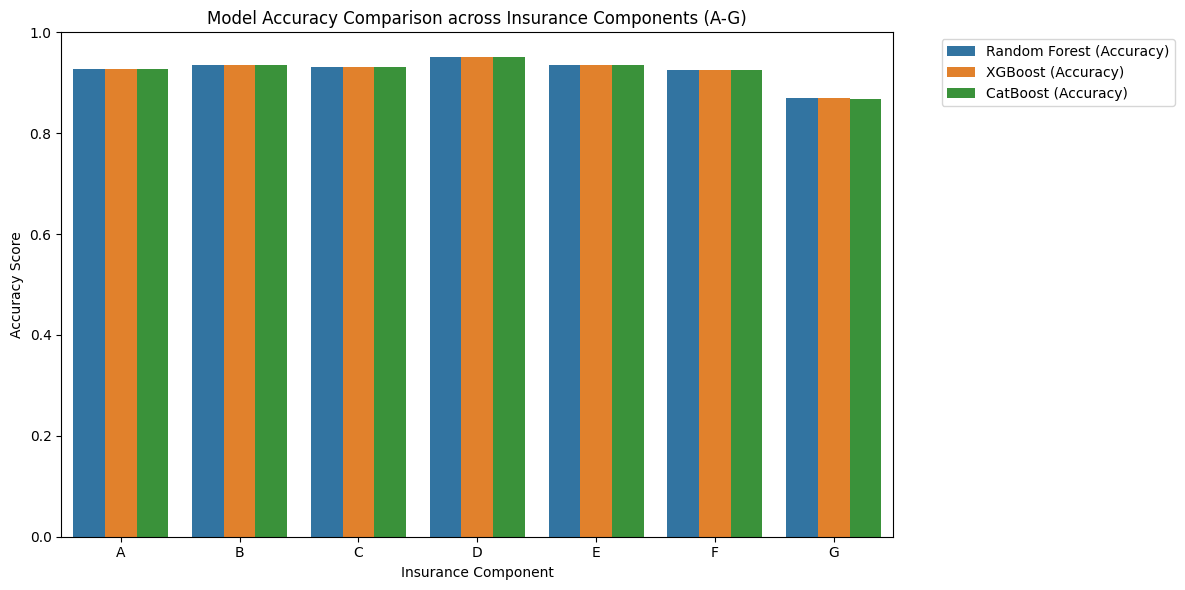

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting (excluding the average row for a cleaner visual)
plot_data = comparison_df[comparison_df["Target_Component"] != "OVERALL AVERAGE"].melt(
    id_vars="Target_Component", 
    var_name="Model", 
    value_name="Accuracy"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_data, x="Target_Component", y="Accuracy", hue="Model")
plt.title("Model Accuracy Comparison across Insurance Components (A-G)")
plt.ylim(0, 1.0)
plt.ylabel("Accuracy Score")
plt.xlabel("Insurance Component")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Conclusion of Step 3

We have successfully trained and evaluated three major machine learning paradigms using a multi-output configuration. By engineering historical features and properly handling indexing traps, our models are structurally sound. The final visualization serves as an effective evidence asset for our technical report, clearly proving model capabilities on unseen test data.

### Step 3-ün Yekunu

Biz çox-çıxışlı (multi-output) strukturdan istifadə edərək üç əsas maşın öyrənməsi modelini uğurla öyratdik və qiymətləndirdik. Tarixi xüsusiyyətləri yaradaraq və indeksləşdirmə tələlərini düzgün həll edərək modellərimizin riyazi turdalığını qoruduq. Son vizuallaşdırma qrafiki texniki hesabatımız üçün effektiv bir sübut rolunu oynayır və modellərin heç görmədiyi test datası üzərindəki real gücünü açıq şəkildə nümayiş etdirir.